# CPJUMP1 → SpatialData

`cpio.read_plate` reads one plate of a Cell Painting Gallery source into a [SpatialData](https://spatialdata.scverse.org) object.
Fields of view become Images, the CellProfiler Nuclei, Cells and Cytoplasm segmentations become Labels, the wells become Shapes, and the well- and cell-level measurements become the `wells` and `cells` Tables.

Objects are Labels rather than Shapes because CellProfiler is pixel-based: it measures on masks, so a polygon would be a lossy conversion.
The gallery publishes one-pixel outlines rather than masks, so the labels are reconstructed from them and carry CellProfiler's own object numbers, which is what lets the `cells` table annotate them.

Every element sits in three coordinate systems - its field, its well, and its plate - built from the stage coordinates in `load_data.csv` plus the nominal 4.5 mm well pitch of a 384-well plate.

The images of this source run to tens of terabytes, so this takes two wells of each of two plates.
`read_plate` reads back whatever is on disk, and the well-level table covers the whole plate either way.

```bash
for plate in BR00116991 BR00117026; do
  for well in A02 C09; do
    python fetch.py cpg0000-jump-pilot/source_4 2020_11_04_CPJUMP1 $plate $well
  done
done
```

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

import numpy as np
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from matplotlib.colors import Normalize

import cell_painting_io as cpio

# ome-zarr logs a line per label element on read, and spatialdata-plot warns once per element it subsets out
logging.getLogger("ome_zarr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The table is annotating .*, which is not present")

DATA_ROOT = Path("~/data/cpg0000-jump-pilot/source_4").expanduser()
BATCH = "2020_11_04_CPJUMP1"
PLATES = ("BR00116991", "BR00117026")


def grey(sdata, element, channel="DNA"):
    values = sd.get_pyramid_levels(sdata[element], n=0).sel(c=channel).to_numpy()
    return {
        "channel": channel,
        "cmap": "gray",
        "norm": Normalize(*np.percentile(values, [50, 99.9])),
        "colorbar": False,
    }

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sdatas = {plate: cpio.read_plate(DATA_ROOT, BATCH, plate) for plate in PLATES}
sdatas[PLATES[0]]

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'BR00116991_A02_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s2_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s3_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s4_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s5_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s6_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s7_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s8_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s9_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_C09_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)


Element names and coordinate systems carry the plate barcode, so two plates concatenate without renaming.
The two tables are named the same in both, so `concatenate_tables=True` stacks them while the region column keeps pointing each row at its own element.

In [3]:
merged = sd.concatenate(sdatas.values(), concatenate_tables=True)
print(f"{len(merged.images)} images, {len(merged.labels)} labels, {len(merged.shapes)} shapes")
print(f"{len(merged.coordinate_systems)} coordinate systems")
for name, table in merged.tables.items():
    print(f"table {name!r}: {table.shape}")

for name, sdata in sdatas.items():
    sdata.write(DATA_ROOT / f"{name}.zarr", overwrite=True)

36 images, 108 labels, 2 shapes
42 coordinate systems
table 'cells': (2678, 1938)
table 'wells': (768, 904)


The nine fields of a well drawn in the well coordinate system, which is the transformation doing the work: each image sits on its own pixel grid and only the translation puts it in place.
The holes are the seven positions of the 4x4 grid that the microscope did not visit.

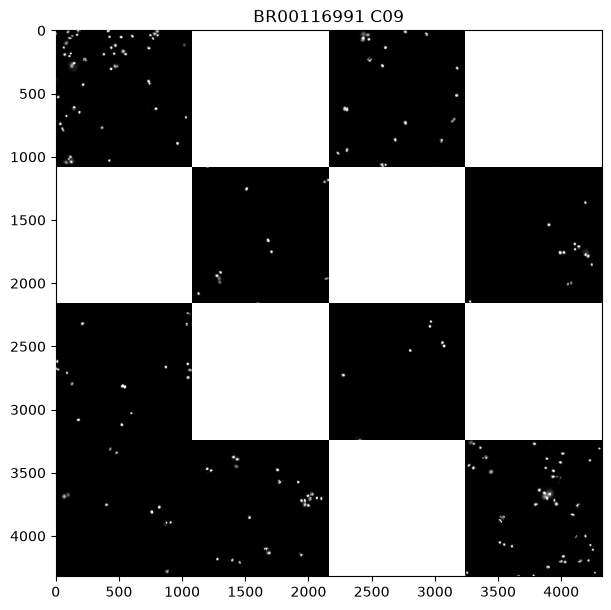

In [4]:
plate = PLATES[0]
(
    sdatas[plate]
    .pl.render_images(**grey(sdatas[plate], f"{plate}_C09_s1_image"))
    .pl.show(coordinate_systems=f"{plate}_C09", figsize=(6, 6), title=f"{plate} C09")
)

And the cell masks over the DNA channel of one field, coloured by a column of the cell table, which is the join the label values were built for.

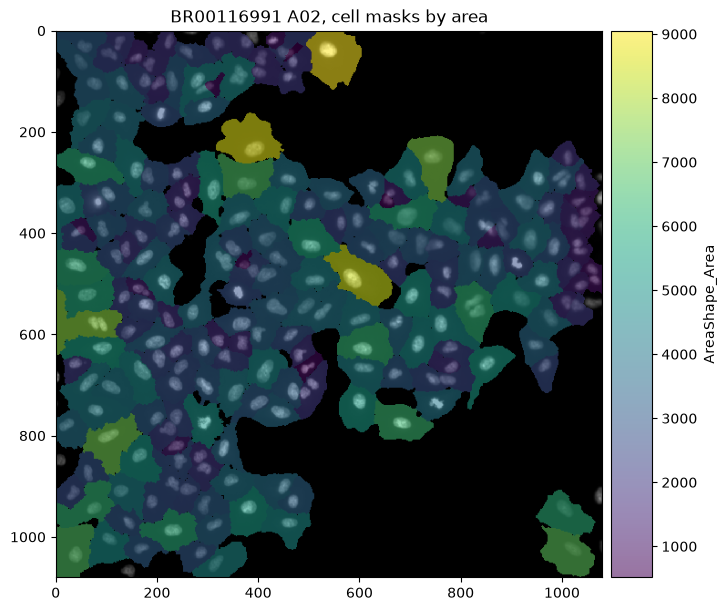

In [5]:
element = f"{plate}_A02_s1_image"
(
    sdatas[plate]
    .pl.render_images(element, **grey(sdatas[plate], element))
    .pl.render_labels(f"{plate}_A02_s1_cells", color="AreaShape_Area", table_name="cells", fill_alpha=0.55)
    .pl.show(coordinate_systems=f"{plate}_A02_s1", figsize=(6.5, 6), title=f"{plate} A02, cell masks by area")
)